<a href="https://colab.research.google.com/github/hiranshree/Repo/blob/main/weather_sensitivity_heatmap_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

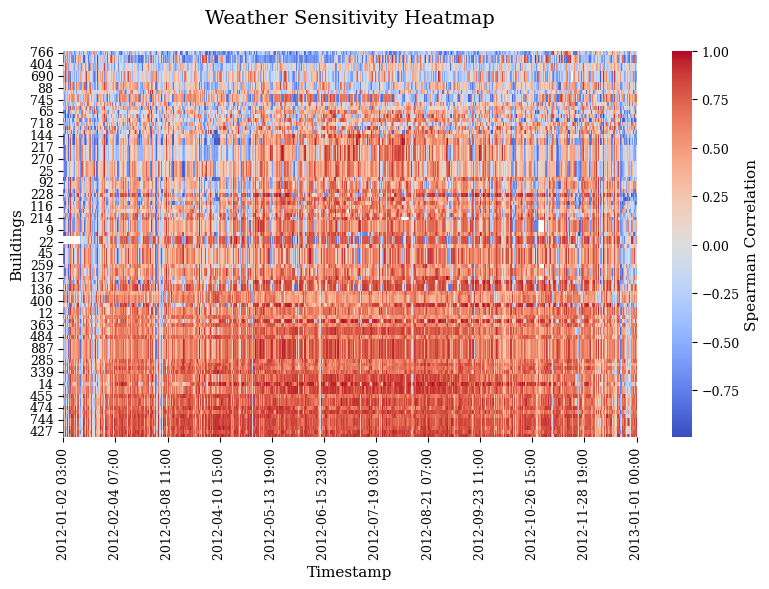

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from pathlib import Path

def weather_sensitivity_plot(electricity_file, weather_file, window_size=24):
    # --- LATEX FONT CONFIGURATION ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.edgecolor": "black",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    # 1. Load data
    elec_df = pd.read_csv(electricity_file, parse_dates=['Timestamp'])
    weather_df = pd.read_csv(weather_file, parse_dates=['DateTime'])

    # Standardize column name
    weather_df.rename(columns={'temperature_2m': 'air_temperature'}, inplace=True)
    weather_df.rename(columns={'DateTime': 'Timestamp'}, inplace=True)

    # 2. Merge and Filter
    df = pd.merge(elec_df, weather_df[['Timestamp', 'air_temperature']], on='Timestamp', how='inner')
    df = df.sort_values('Timestamp').reset_index(drop=True)

    building_cols = [col for col in df.columns if col not in ['Timestamp', 'air_temperature']]
    df[building_cols] = df[building_cols].map(lambda x: np.nan if x <= 0 else x)

    # 3. Compute Rolling Correlations
    n_windows = len(df) - window_size + 1
    corr_df = pd.DataFrame(index=df.index[window_size - 1:])

    for col in building_cols:
        corr_values = []
        for start in range(n_windows):
            window = df.iloc[start:start + window_size]
            valid = window[[col, 'air_temperature']].dropna()

            # Require at least 5 points for a valid correlation
            if len(valid) > 5 and valid[col].std() != 0 and valid['air_temperature'].std() != 0:
                corr, _ = spearmanr(valid[col], valid['air_temperature'])
                corr_values.append(corr)
            else:
                corr_values.append(np.nan)
        corr_df[col] = corr_values

    # 4. SORTING: Ascending order of mean correlation
    mean_correlations = corr_df[building_cols].mean().sort_values(ascending=True)
    sorted_buildings = mean_correlations.index.tolist()
    plot_df = corr_df[sorted_buildings]

    # 5. Generate Heatmap
    plt.figure(figsize=(8, 6)) # Consistent with other scripts

    ax = sns.heatmap(
        plot_df.T,
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Spearman Correlation'}
    )

    # 6. Formatting
    plt.title('Weather Sensitivity Heatmap', pad=20)
    plt.xlabel("Timestamp")
    plt.ylabel("Buildings")

    plt.yticks(rotation=0)

    # Match X-axis tick density and rotation
    xticks = np.linspace(0, len(plot_df) - 1, 12).astype(int)
    ax.set_xticks(xticks)

    # Ensure labels account for the window shift
    tick_labels = df['Timestamp'].iloc[xticks + (window_size - 1)].dt.strftime('%Y-%m-%d %H:%M')
    ax.set_xticklabels(tick_labels, rotation=90)

    # Save handling
    plt.tight_layout()
    output_path = Path('Enernoc_weather_sensitivity_heatmap.png')
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=600, bbox_inches='tight')

    plt.show()

# Execution
weather_sensitivity_plot('/content/Electricity-hourly.csv', '/content/Weather_Data.csv')